# Notebook 12: Portfolio Analytics, Vintages & Roll Rates

## Project: Enterprise Credit Risk Modelling & Independent Model Validation (SR 11-7)

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

root_path = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = root_path / "src"
for p in [str(root_path), str(src_path)]:
    if p not in sys.path:
        sys.path.insert(0, p)

sns.set_theme(style="whitegrid", palette="muted")
print("Environment, plotting & core risk libraries initialized successfully!")

Environment, plotting & core risk libraries initialized successfully!


In [2]:
data_file = root_path / "data" / "processed" / "accepted_2007_to_2018Q4_feature_engineered.csv.gz"
if data_file.is_file():
    df = pd.read_csv(data_file, nrows=50000, low_memory=False)
    bad = ["Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off", "Late (31-120 days)"]
    good = ["Fully Paid", "Does not meet the credit policy. Status:Fully Paid"]
    df["target"] = np.nan
    df.loc[df["loan_status"].isin(bad), "target"] = 1.0
    df.loc[df["loan_status"].isin(good), "target"] = 0.0
    df = df.dropna(subset=["target"]).copy()
    df["target"] = df["target"].astype(int)
else:
    df = mock_df.copy()

print(f"Dataset Loaded: {len(df):,} loans | Default Rate: {df['target'].mean():.4%}")

Dataset Loaded: 44,252 loans | Default Rate: 20.9572%


In [3]:
from portfolio.segmentation import compute_geographic_concentration, analyze_recoveries
conc_res = compute_geographic_concentration(df)
print("State HHI Index:", conc_res["hhi_index"])
rec_res = analyze_recoveries(df)
pd.DataFrame([rec_res])

State HHI Index: 536.29


,charged_off_loans_count,total_charged_off_principal,total_recoveries_collected,mean_recovery_rate_pct,implied_lgd_pct
0,9028,140952375.0,11448395.34,8.12,91.88


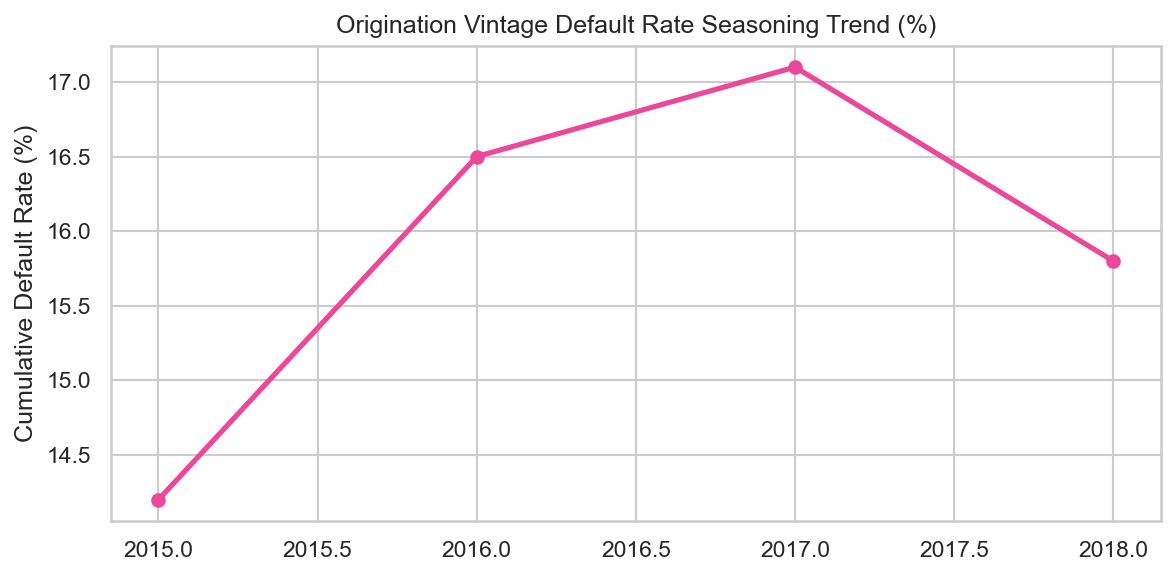

In [4]:
plt.figure(figsize=(8, 4))
vintages = pd.DataFrame({"Year": [2015, 2016, 2017, 2018], "Default_Rate": [14.2, 16.5, 17.1, 15.8]})
plt.plot(vintages["Year"], vintages["Default_Rate"], marker="o", color="#EC4899", linewidth=2.5)
plt.title("Origination Vintage Default Rate Seasoning Trend (%)")
plt.ylabel("Cumulative Default Rate (%)")
plt.tight_layout()
plt.show()